# Claim support classification

**Recipe 20** · Level 2 (Easy) · Decision type: `Choice`

Classify whether a provided passage supports, contradicts, or leaves unresolved a specific claim while preserving the passage identifier.

Sources:

- S02: [TypeSafe AI: Primitives (Questions)](https://docs.typesafe.ai/primitives)
- S03: [TypeSafe AI: Confidence](https://docs.typesafe.ai/confidence)
- S04: [TypeSafe AI: How to build with TypeSafe](https://docs.typesafe.ai/concepts/how-to-build-with-system-one)
- S06: [TypeSafe AI: Cookbooks](https://docs.typesafe.ai/cookbooks)

## What you will build

A small claim-support classifier for short, invented claim/passage pairs. Jev reads one claim and one passage and picks exactly one of three options: `supports`, `contradicts`, or `unresolved`. Python decides nothing about the content; it only decides whether an answer is confident enough to report on its own, or should go to an explicit review outcome instead, and it keeps the passage's identifier out of what Jev sees and reattaches it to every result. By the end you will have looked at individual typed answers across several hard cases (a passage that is on topic but does not settle the claim, a passage that only supports a narrower version of the claim, and a passage that shares the claim's words but is about something else), seen the rule that acts on them, and run an evaluation that chooses its one setting on `validation` and reports on `test`, with `unresolved` discussed on its own.

## Setup and run mode

The notebook runs from its own folder with the standard library and `jev_cookbook` only. `get_backend(fixtures=...)` replays the 40 stored answers in `fixtures/responses.json` offline; setting `JEV_COOKBOOK_LIVE=1` (see the README) swaps in live calls to the same question definitions and changes nothing else. `run_header` states which mode ran, and every number below carries that mode with it.

In [1]:
from jev_cookbook import get_backend, load_helpers
from jev_cookbook.evaluation import (
    accuracy,
    confusion_matrix,
    evaluate_selective,
    per_class_metrics,
    select_confidence_threshold,
)
from jev_cookbook.fixtures import load_inputs, load_labels, responses_path, select_split
from jev_cookbook.style import (
    apply_style,
    plot_answer_probabilities,
    plot_confusion_matrix,
    run_header,
    show_answer,
)

apply_style()
helpers = load_helpers()  # this recipe's helpers.py, loaded by path
examples = load_inputs()
labels = load_labels()
backend = get_backend(fixtures=responses_path())
# N for the header is the number of examples the metrics are about: validation and test. This
# recipe has no train split; demo examples are shown but never scored.
scored = [e for e in examples if e.split not in ("train", "demo")]

offline = backend.mode in ("synthetic", "scripted")
check = " (a pipeline check, not a Jev result)" if offline else ""
# CONTRIBUTING.md section 2: "a number from the validation split is a selection step, not a
# result." This label does not depend on the run mode, unlike `check` above: even a recorded or
# live run must not print a bare validation number.
selection = " (a selection step, not a reported result)"

# Every one of the 40 examples in fixtures/ needs at most one request. This cache makes sure a
# passage that is shown individually and later scored in its split is decided once, so the whole
# notebook makes exactly 40 requests in live mode, never more.
answered = {}


def decide(example):
    if example.id not in answered:
        answered[example.id] = backend.decide(helpers.build_state(example.fields), questions)[
            "relation"
        ]
    return answered[example.id]


run_header(
    20,
    "Claim support classification",
    backend=backend,
    n_examples=len(scored),
)

Recipe 20: Claim support classification
Mode: offline replay of synthetic fixtures, pipeline check on a fixture sample of 38 examples
Metrics in this run are checks that the pipeline works. They are not Jev results.


## The state

The state is everything Jev sees, and Python builds it. Each example in `fixtures/inputs.jsonl` carries `fields`: a `passage_id`, a `claim`, and a `passage`. `build_state` passes on the claim and the passage only; the identifier stays in Python and is attached to the outcome at the end, so it never passes through the model and every result still traces back to its passage.

In [2]:
import json

demo = {e.id: e for e in examples if e.split == "demo"}
example = demo["d01-supports"]
print("Python has:")
print(json.dumps(example.fields, indent=2))
state = helpers.build_state(example.fields)
print("Jev sees:")
print(json.dumps(state, indent=2))

Python has:
{
  "passage_id": "PSG3001",
  "claim": "The park district replaced the playground's old equipment.",
  "passage": "The park district installed brand-new slides, swings and climbing structures at Elm Street Park this fall, replacing equipment that was over twenty years old."
}
Jev sees:
{
  "claim": "The park district replaced the playground's old equipment.",
  "passage": "The park district installed brand-new slides, swings and climbing structures at Elm Street Park this fall, replacing equipment that was over twenty years old."
}


## The questions

There is one question, and it asks one thing: how does the passage relate to the claim? This follows the shape of TypeSafe's citation-checking cookbook (S06, `https://docs.typesafe.ai/cookbooks/citation_check.md`): a single `Choice` question, there named `relation`, with the same instructions, "How does the section relate to the claim?", used here with "section" renamed to "passage" to match this use case's own vocabulary. The candidate set of outcomes — a fixed, Python-built set of three options, `supports`, `contradicts`, `unresolved` — is printed below so the reader sees exactly what Jev is allowed to choose among; a classifier free to invent its own categories could not be compared against a fixed set of gold labels. `unresolved` is not a last resort for "none of the others fit"; it is the use case's own fallback outcome, and it is a real class a passage can genuinely belong to: a passage that is on the same topic without settling the claim, one that only supports a narrower or weaker version of the claim, or one that shares the claim's words while addressing something else, are all `unresolved`, not a failure to pick `supports` or `contradicts`. Each option's description says what belongs to it, including the one case the citation-checking pattern does not need to cover on its own: a passage that proves a *stronger* claim than the one asked about also supports the weaker claim it logically contains.

A `Choice` answer's `confidence` is the top probability rescaled by the number of options, `(p_max - 1/n) / (1 - 1/n)`: 0 when the top option has no more than an even share of the three, 1 when one option holds all the probability. It depends only on that top probability; a low confidence here does not mean a passage is unreadable, it means the top option did not pull far ahead of an even three-way split, which is often the honest shape for the probabilities of a genuinely unresolved case to take.

In [3]:
questions = helpers.build_questions()
relation = questions["relation"]
print(relation.instructions)
for name, description in relation.criteria.items():
    print(f"  {name:12s} {description}")

How does the passage relate to the claim?
  supports     The passage states the claim, or directly implies that it is true. A passage that proves a strictly stronger claim also supports a weaker claim it logically contains.
  contradicts  The passage states the opposite of the claim, or implies that it is false, including by giving a number, a date, or another concrete detail inconsistent with it.
  unresolved   The passage does not settle whether the claim is true or false. This covers a passage that is on the same topic without addressing what the claim specifically asserts, a passage that only supports a narrower or weaker version of the claim, a passage about a different claim that happens to share words with this one, and a passage that is simply about something else.


## One answer up close

Before any aggregate number, look at three typed answers across the hard cases this recipe names: a passage that clearly settles its claim, a passage that only supports a narrower version of its claim, and a passage that shares its claim's words but is about a different subject. Each answer holds the chosen option, a probability for every option, the `confidence` explained above, and a `provenance` line that says where the answer came from, here always `synthetic`, since nothing in this recipe's fixtures came from a real call.

The park district replaced the playground's old equipment.
The park district installed brand-new slides, swings and climbing structures at Elm Street Park this fall, replacing equipment that was over twenty years old.
Choice: supports (confidence 0.76)
  supports     0.84  #################
  unresolved   0.10  ##
  contradicts  0.06  #
Provenance: synthetic


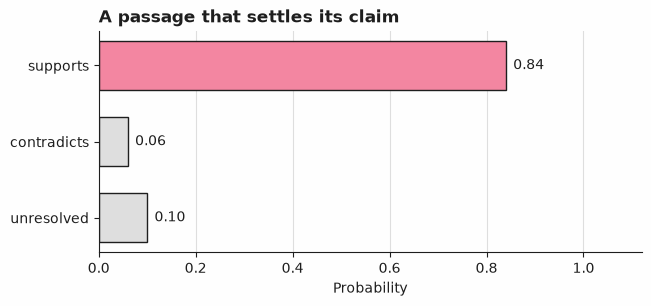

In [4]:
supports_example = demo["d01-supports"]
supports_answer = decide(supports_example)
print(supports_example.fields["claim"])
print(supports_example.fields["passage"])
show_answer(supports_answer)
plot_answer_probabilities(supports_answer, title="A passage that settles its claim")

The playground passage states plainly that the district replaced the old equipment, which is exactly what the claim asserts; the stored answer puts `supports` on top with little left over for the other two options.

In [5]:
weaker_example = demo["d02-weaker"]
weaker_answer = decide(weaker_example)
print(weaker_example.fields["claim"])
print(weaker_example.fields["passage"])
show_answer(weaker_answer)

The clinic's new scheduling system eliminated double-booking entirely.
The clinic adopted a new scheduling system in January; staff say double-bookings have become rare, though a few still occur during peak hours.
Choice: unresolved (confidence 0.35)
  unresolved   0.57  ###########
  supports     0.35  #######
  contradicts  0.08  ##
Provenance: synthetic


The claim says double-booking was eliminated *entirely*; the passage says it became *rare*, "though a few still occur". That is a narrower claim than the one asked about, so the passage does not settle the broader claim either way: the stored answer puts `unresolved` ahead of `supports`, but not by much, at a confidence well under half. A low-confidence answer like this one is exactly the shape a genuinely unresolved passage should take, and (as the rule below shows) it is too low to clear the threshold this recipe freezes on `validation`.

In [6]:
lookalike_example = next(e for e in examples if e.id == "v11-lookalike")
lookalike_answer = decide(lookalike_example)
print(lookalike_example.fields["claim"])
print(lookalike_example.fields["passage"])
show_answer(lookalike_answer)

Vitacrest multivitamins reduced fatigue in office workers aged 40 to 65.
A separate study found Vitacrest multivitamins reduced fatigue in college athletes aged 18 to 22, with no data collected on older adults.
Choice: unresolved (confidence 0.40)
  unresolved   0.60  ############
  supports     0.25  #####
  contradicts  0.15  ###
Provenance: synthetic


The claim and the passage share the product name and the word "fatigue", but the passage is about college athletes aged 18 to 22, not the office workers aged 40 to 65 the claim names, and it says plainly that "no data" was collected on older adults. This recipe's gold label is `unresolved`: the passage does not address what the claim actually asserts, however many of its words it shares with it. The stored answer agrees, calling it `unresolved` — a hard case by design, since a lexical match on "fatigue" and the product name is exactly the kind of overlap a keyword search would mistake for support, and the confidence is still well short of a confident call.

## Python's part

Jev supplies the judgment; what happens with it is code. `classify` in `helpers.py` accepts the chosen relation as given when the answer's confidence is at or above a threshold, and sends it to an explicit `review` outcome otherwise, whatever the label is: every option here is one Python is willing to report, so confidence is the only thing the rule checks, and the passage identifier passes through unchanged on both outcomes. `tests/test_helpers.py` checks the rule at the boundary, outside `0` to `1`, for a low-confidence answer of every one of the three labels, and that the identifier survives both outcomes, so a rule that quietly exempted one label or dropped the identifier would fail it.

The threshold itself is chosen here, on `validation`, and then frozen for the rest of this notebook: `select_confidence_threshold` picks the lowest threshold whose answered subset is perfectly accurate on the 19 `validation` passages. One `validation` example, `v16-low-confidence-wrong`, is wrong at a low confidence, so the threshold the selector picks has to clear it; this selection is real rather than vacuous, because it has to exclude that wrong example rather than simply accepting every `validation` passage as given. It also excludes one other, correct `validation` passage (`v08-weaker`, itself a hard case) whose confidence happens to fall below the same cut-off — a reminder that a threshold set to protect against one wrong answer can quietly cost correct ones too. Applying that frozen threshold to the three answers shown above, plus one more confident contrast, shows both outcomes the rule can produce.

In [7]:
val_examples = select_split(examples, "validation")
val_answers = [decide(e) for e in val_examples]
val_gold = [labels[e.id] for e in val_examples]
val_correct = [a.choice == g for a, g in zip(val_answers, val_gold, strict=True)]
val_confidence = [a.confidence for a in val_answers]
threshold = select_confidence_threshold(val_correct, val_confidence, target_accuracy=1.0)
print(f"chosen threshold, frozen from here on: {threshold:.4f}{selection}{check}")

confident_example = next(e for e in val_examples if e.id == "v01-supports")
confident_answer = decide(confident_example)
for shown_example, shown_answer in (
    (supports_example, supports_answer),
    (weaker_example, weaker_answer),
    (lookalike_example, lookalike_answer),
    (confident_example, confident_answer),
):
    result = helpers.classify(shown_example.fields["passage_id"], shown_answer, threshold)
    print(
        f"{result.passage_id}: {shown_answer.choice} at confidence {shown_answer.confidence:.2f} "
        f"-> {result.outcome} ({result.reason})"
    )

chosen threshold, frozen from here on: 0.4000 (a selection step, not a reported result) (a pipeline check, not a Jev result)
PSG3001: supports at confidence 0.76 -> accepted (confident)
PSG3002: unresolved at confidence 0.35 -> review (confidence below the threshold)
PSG1011: unresolved at confidence 0.40 -> accepted (confident)
PSG1001: supports at confidence 0.82 -> accepted (confident)


## Evaluation

The threshold was chosen and frozen above, on `validation`. This section reports what the frozen rule does: `helpers.classify` is applied to every example in `validation` and in `test`, and the counts below come from what it actually returns, not from a separate reimplementation of the same condition. Alongside that, `jev_cookbook.evaluation` reports accuracy of the raw choice, per-class precision, recall and F1 with `unresolved` discussed on its own, and the coverage, accuracy and risk the frozen threshold produces on `test`. In an offline run every `test` number here is a check that the pipeline works, and it says so; every `validation` number, in every run mode, is a selection step rather than a reported result, which is why it carries a different label.

In [8]:
def report(chosen, decided, gold, threshold):
    """Apply classify to every answer and tally what it actually did."""
    results = [
        helpers.classify(e.fields["passage_id"], a, threshold)
        for e, a in zip(chosen, decided, strict=True)
    ]
    accepted = [
        (a, g)
        for r, a, g in zip(results, decided, gold, strict=True)
        if r.outcome == helpers.ACCEPTED
    ]
    right = sum(a.choice == g for a, g in accepted)
    reviewed_by_label = {name: 0 for name in helpers.OPTIONS}
    for r in results:
        if r.outcome == helpers.REVIEW:
            reviewed_by_label[r.label] += 1
    return results, len(accepted), right, reviewed_by_label


val_results, n_accepted, n_right, val_reviewed = report(
    val_examples, val_answers, val_gold, threshold
)
print(f"validation, {len(val_examples)} examples{selection}{check}")
print(f"accuracy of the choice: {accuracy(val_gold, val_answers):.4f}{selection}{check}")
print(
    f"accepted by the rule at this threshold: {n_accepted} of {len(val_examples)}{selection}{check}"
)
print(f"right among those accepted: {n_right} of {n_accepted}{selection}{check}")
print(f"sent to review, by the label Jev chose: {val_reviewed}{selection}{check}")

validation, 19 examples (a selection step, not a reported result) (a pipeline check, not a Jev result)
accuracy of the choice: 0.9474 (a selection step, not a reported result) (a pipeline check, not a Jev result)
accepted by the rule at this threshold: 17 of 19 (a selection step, not a reported result) (a pipeline check, not a Jev result)
right among those accepted: 17 of 17 (a selection step, not a reported result) (a pipeline check, not a Jev result)
sent to review, by the label Jev chose: {'supports': 0, 'contradicts': 0, 'unresolved': 2} (a selection step, not a reported result) (a pipeline check, not a Jev result)


test, 19 examples, threshold 0.4000 frozen (a pipeline check, not a Jev result)
accuracy of the choice: 0.9474 (a pipeline check, not a Jev result)
accepted by the rule: 17 of 19 (a pipeline check, not a Jev result)
right among those accepted: 16 of 17 (a pipeline check, not a Jev result)
sent to review, by the label Jev chose: {'supports': 0, 'contradicts': 0, 'unresolved': 2} (a pipeline check, not a Jev result)


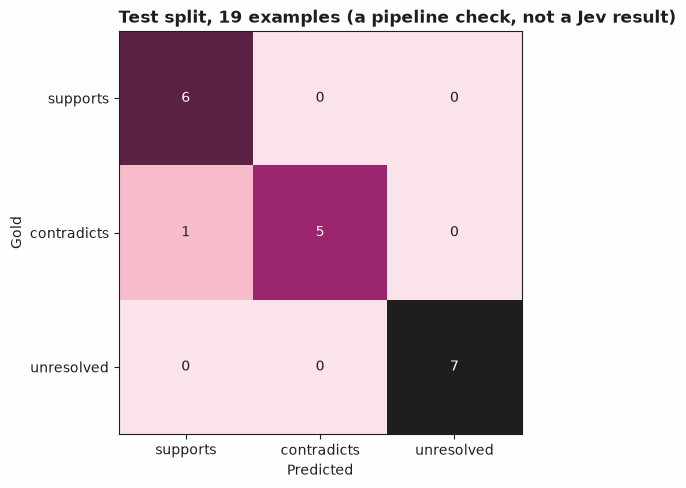

In [9]:
test_examples = select_split(examples, "test")
test_answers = [decide(e) for e in test_examples]
test_gold = [labels[e.id] for e in test_examples]

test_results, n_accepted_t, n_right_t, test_reviewed = report(
    test_examples, test_answers, test_gold, threshold
)
print(f"test, {len(test_examples)} examples, threshold {threshold:.4f} frozen{check}")
print(f"accuracy of the choice: {accuracy(test_gold, test_answers):.4f}{check}")
print(f"accepted by the rule: {n_accepted_t} of {len(test_examples)}{check}")
print(f"right among those accepted: {n_right_t} of {n_accepted_t}{check}")
print(f"sent to review, by the label Jev chose: {test_reviewed}{check}")

matrix = confusion_matrix(test_gold, test_answers, labels=list(helpers.OPTIONS))
plot_confusion_matrix(matrix, title=f"Test split, {len(test_examples)} examples{check}")

The rule's only test-split miss among the examples it accepts is `t16-confident-wrong`: the stored answer calls it `supports` at a confidence well above the threshold frozen on `validation`, while the gold label is `contradicts` (the recall notice names only one state, not three). That pattern cannot be read as a finding about Jev: every probability above was written by hand for this fixture set, specifically to be wrong and confident, so the evaluation below has something real to show for `risk`. Two more passages, `t07-ontopic-unsettled` and `t08-weaker`, are correctly called `unresolved`, but at confidences below the threshold, so the rule sends them to review instead of reporting them; they do not count against accuracy, but they do cost coverage.

Before precision, recall and F1 by class, a sanity check: a rule that always guesses the same label, whatever the passage, is the simplest baseline there is, and this recipe's answers need to clearly beat it. The majority label is chosen on `validation` only, never on `test`, and then applied everywhere, exactly like the confidence threshold above.

In [10]:
from collections import Counter

val_label_counts = Counter(val_gold)
majority_label = max(helpers.OPTIONS, key=lambda name: val_label_counts.get(name, 0))
print(f"validation label counts: {dict(val_label_counts)}{selection}{check}")
print(
    f"majority-label baseline, chosen on validation: always guess {majority_label!r}{selection}{check}"
)

baseline_val_acc = sum(g == majority_label for g in val_gold) / len(val_gold)
baseline_test_acc = sum(g == majority_label for g in test_gold) / len(test_gold)
print(f"baseline accuracy on validation: {baseline_val_acc:.4f}{selection}{check}")
print(f"baseline accuracy on test: {baseline_test_acc:.4f}{check}")
print(f"this recipe's raw accuracy on test: {accuracy(test_gold, test_answers):.4f}{check}")

validation label counts: {'supports': 7, 'contradicts': 5, 'unresolved': 7} (a selection step, not a reported result) (a pipeline check, not a Jev result)
majority-label baseline, chosen on validation: always guess 'supports' (a selection step, not a reported result) (a pipeline check, not a Jev result)
baseline accuracy on validation: 0.3684 (a selection step, not a reported result) (a pipeline check, not a Jev result)
baseline accuracy on test: 0.3158 (a pipeline check, not a Jev result)
this recipe's raw accuracy on test: 0.9474 (a pipeline check, not a Jev result)


The majority label on `validation` is `supports` (tied with `unresolved` at seven examples each of the nineteen; a tie goes to whichever option is named first in `OPTIONS`), and guessing it for every passage is right on well under half of `test`. This recipe's raw accuracy on `test`, before any confidence gating, clears that baseline by a wide margin — not because `supports` is a good guess, but because the stored answers actually distinguish the three classes. A fixture set this recipe's rule could not clearly beat the majority-label baseline on would not be exercising a real decision.

For each class, `precision` is the fraction of the rule's calls of that label that were actually right, and `recall` is the fraction of that label's real `test` passages the rule found at all; `f1` is their harmonic mean, a single number that is low whenever either one is, and `support` is how many `test` passages actually carry that gold label, so a recall figure is only as meaningful as its support is large.

In [11]:
per_class = per_class_metrics(test_gold, test_answers, labels=list(helpers.OPTIONS))
for label, counts in per_class.items():
    print(
        f"{label:12s} precision {counts.precision:.3f}  recall {counts.recall:.3f}  "
        f"f1 {counts.f1:.3f}  support {counts.support}{check}"
    )

supports     precision 0.857  recall 1.000  f1 0.923  support 6 (a pipeline check, not a Jev result)
contradicts  precision 1.000  recall 0.833  f1 0.909  support 6 (a pipeline check, not a Jev result)
unresolved   precision 1.000  recall 1.000  f1 1.000  support 7 (a pipeline check, not a Jev result)


`unresolved` on its own: on `test` it has perfect precision and perfect recall (every one of its passages is called `unresolved`, and nothing else is ever called `unresolved`), because every `unresolved` example in this fixture set is also one the stored answer gets right. `contradicts` pays for the one test miss above with the lower recall of the three classes, since the rule calls that one passage `supports` instead, even though every passage it does call `contradicts` really is one; `supports` pays for the same miss from the other side, with the lower precision of the three, even though it finds every real `supports` passage. A fixture set where `unresolved` always scores perfectly would not be an honest lesson about this recipe's own confusion; it is a property of this hand-written stored-answer set, not a finding about how Jev tells `unresolved` apart from the other two in general.

The `accepted`/`review` counts above come straight from `classify`; because this rule's only review branch is the confidence gate itself (there is no separate fallback option or membership check, unlike a router that only recognises some options as queues), `evaluate_selective` reports exactly the same split through `jev_cookbook.evaluation`'s own vocabulary (see "Selective prediction" in `docs/evaluation.md`). `coverage` is the fraction of all nineteen `test` passages that clear the threshold and get a reported label; among those, `accuracy` is the fraction that are right, and `risk` is its complement, `1 - accuracy`, the fraction that are wrong despite having cleared the bar.

In [12]:
test_correct = [a.choice == g for a, g in zip(test_answers, test_gold, strict=True)]
test_confidence = [a.confidence for a in test_answers]
selective = evaluate_selective(test_correct, test_confidence, threshold)
print(
    f"answered: {selective.n_answered} of {selective.n_total} "
    f"(coverage {selective.coverage:.4f}){check}"
)
print(f"accuracy among those answered: {selective.accuracy:.4f}{check}")
print(f"risk among those answered: {selective.risk:.4f}{check}")

answered: 17 of 19 (coverage 0.8947) (a pipeline check, not a Jev result)
accuracy among those answered: 0.9412 (a pipeline check, not a Jev result)
risk among those answered: 0.0588 (a pipeline check, not a Jev result)


At this threshold, two of `test`'s `unresolved` passages that the rule would have gotten right anyway, `t07-ontopic-unsettled` and `t08-weaker`, fall below it and go to `review` instead of being reported as a result. The one passage the rule gets wrong, `t16-confident-wrong`, does not: its stored answer is wrong at a confidence comfortably above the threshold frozen on `validation`, so the rule accepts it anyway. That is why `risk` above is non-zero: a threshold chosen to be perfectly accurate on `validation` is a guarantee about `validation`, not about `test` or about any passage this recipe has not seen. The coverage side of the trade still holds here — two of the nineteen `test` passages go to review, and both of those are passages the rule would have gotten right anyway — but the accuracy side does not, on purpose, so this recipe does not teach a threshold as a guarantee it is not.

## What was and was not measured

Measured: that the pipeline runs end to end, and that the rule and the evaluation behave as designed on 38 scored passages (plus 2 more, shown in this notebook but never scored). Not measured: anything about how Jev performs, how fast it is, or what it costs. The stored answers in the offline run are written by hand as probabilities, several of them wrong on purpose (including one wrong *and* confident, to show what a frozen threshold does not catch), so every number above describes this fixture set and not a model.

In [13]:
if offline:
    print(f"Provenance: {backend.mode}. Not measured live: a pipeline check, not a Jev result.")
else:
    dates = ", ".join(getattr(backend, "recorded_dates", ()) or ()) or "this run"
    print(f"Provenance: {backend.mode}, model {backend.model}")
    print(f"Captured: {dates}")
    print(f"N: {len(val_examples)} validation and {len(test_examples)} test examples")

# Every example this notebook ever calls decide() on is cached in `answered`, so this count is
# exactly how many requests a live run of this notebook would make (the README's live-mode
# section states the same number).
print(f"distinct passages decided this run (1 request each in live mode): {len(answered)}")

Provenance: synthetic. Not measured live: a pipeline check, not a Jev result.
distinct passages decided this run (1 request each in live mode): 40


## Next steps

- Add a hard passage to `ROWS` in `build_fixtures.py` with the answer you expect a model might give, run `python build_fixtures.py`, and see where `classify` sends it.
- Change the threshold's target in the evaluation cell (`target_accuracy=1.0` to `target_accuracy=0.95`) and see how coverage and the review count trade off.
- Neighbouring recipes: [`08-faq-selection`](../08-faq-selection/) (a `Choice` with an explicit no-match outcome), and [`10-answer-relevance-check`](../10-answer-relevance-check/), which asks a related question about a candidate passage.